In [10]:
import pandas as pd
from pathlib import Path
import re

# ==========================================================
# PATHS
# ==========================================================

BASE_DIR = Path(
    r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\Split"
)

PVECTOR_CSV = Path(
    r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\1436_pvectors.csv"
)

OUTPUT_CSV = BASE_DIR / "labels.csv"

# ==========================================================
# LOAD P-VECTORS
# ==========================================================

pvectors = pd.read_csv(PVECTOR_CSV)

print("Loaded p-vectors:", len(pvectors))

# ==========================================================
# CREATE LABELS
# ==========================================================

rows = []

splits = ["train", "val", "test"]

for split in splits:

    folder = BASE_DIR / split

    for img_path in sorted(folder.glob("*.png")):

        filename = img_path.name

        # --------------------------------------------------
        # Extract femur number
        # --------------------------------------------------

        match = re.search(r"synthetic_femur_(\d+)", filename)

        if match is None:
            print("Skipping:", filename)
            continue

        femur_id = int(match.group(1))

        # CSV rows start from 0
        p = pvectors.iloc[femur_id - 1]

        rows.append({
            "image_name": filename,
            "split": split,
            "p1": p["p1"],
            "p2": p["p2"],
            "p3": p["p3"],
            "p4": p["p4"],
            "p5": p["p5"],
        })

# ==========================================================
# SAVE
# ==========================================================

labels = pd.DataFrame(rows)

labels.to_csv(OUTPUT_CSV, index=False)

print("\nSaved:", OUTPUT_CSV)
print("Total images:", len(labels))
print(labels.head())

Loaded p-vectors: 1436

Saved: C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\Split\labels.csv
Total images: 21540
                       image_name  split        p1        p2        p3  \
0           synthetic_femur_1.png  train -0.500000 -0.500000 -0.500000   
1         synthetic_femur_100.png  train -2.000000 -2.000000  2.000000   
2        synthetic_femur_1000.png  train -0.707188  0.075162  0.812076   
3  synthetic_femur_1000_aug00.png  train -0.707188  0.075162  0.812076   
4  synthetic_femur_1000_aug01.png  train -0.707188  0.075162  0.812076   

         p4        p5  
0 -0.500000 -0.500000  
1  2.000000 -2.000000  
2 -0.545482  1.887128  
3 -0.545482  1.887128  
4 -0.545482  1.887128  


In [11]:
import os
import pandas as pd
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset
from torchvision import transforms

# ==========================================================
# DATASET
# ==========================================================

class FemurDataset(Dataset):

    def __init__(self, labels_csv, image_root, split):

        self.image_root = image_root

        df = pd.read_csv(labels_csv)

        self.df = df[df["split"] == split].reset_index(drop=True)

        self.transform = transforms.Compose([

            transforms.Resize((256,256)),

            transforms.Grayscale(num_output_channels=3),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225]
            )
        ])

    # ------------------------------------------------------

    def __len__(self):

        return len(self.df)

    # ------------------------------------------------------

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = os.path.join(
            self.image_root,
            row["split"],
            row["image_name"]
        )

        image = Image.open(image_path)

        image = self.transform(image)

        target = torch.tensor(
            [
                row["p1"],
                row["p2"],
                row["p3"],
                row["p4"],
                row["p5"]
            ],
            dtype=torch.float32
        )

        return image, target

In [12]:
from torch.utils.data import DataLoader

# ==========================================================
# PATHS
# ==========================================================

LABELS = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\Split\labels.csv"

ROOT = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\Split"

# ==========================================================
# DATASET
# ==========================================================

train_dataset = FemurDataset(
    LABELS,
    ROOT,
    split="train"
)

print("Training Images :", len(train_dataset))

# ==========================================================
# TEST ONE SAMPLE
# ==========================================================

image, label = train_dataset[0]

print("Image shape :", image.shape)

print("Label :", label)

Training Images : 15075
Image shape : torch.Size([3, 256, 256])
Label : tensor([-0.5000, -0.5000, -0.5000, -0.5000, -0.5000])


In [13]:
from torch.utils.data import DataLoader

# ==========================================================
# PATHS
# ==========================================================

LABELS = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\Split\labels.csv"

ROOT = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\Split"

# ==========================================================
# DATASETS
# ==========================================================

train_dataset = FemurDataset(
    labels_csv=LABELS,
    image_root=ROOT,
    split="train"
)

val_dataset = FemurDataset(
    labels_csv=LABELS,
    image_root=ROOT,
    split="val"
)

test_dataset = FemurDataset(
    labels_csv=LABELS,
    image_root=ROOT,
    split="test"
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

# ==========================================================
# DATALOADERS
# ==========================================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("\nDataLoaders created successfully.")

Train: 15075
Validation: 3225
Test: 3240

DataLoaders created successfully.


In [14]:
import timm
import torch
import torch.nn as nn

# ==========================================================
# DEVICE
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

# ==========================================================
# MODEL
# ==========================================================

model = timm.create_model(
    "xception",
    pretrained=True,
    num_classes=5          # Regression output
)

model = model.to(device)

print(model)

Using: cuda


c:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\myenv\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Xception(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU(inplace=True)
  (block1): Block(
    (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (skipbn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (rep): Sequential(
      (0): SeparableConv2d(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
        (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      )
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): SeparableConv2d(
        (conv1): Conv

In [15]:
from torchinfo import summary

summary(
    model,
    input_size=(32, 3, 256, 256)
)

Layer (type:depth-idx)                   Output Shape              Param #
Xception                                 [32, 5]                   --
├─Conv2d: 1-1                            [32, 32, 127, 127]        864
├─BatchNorm2d: 1-2                       [32, 32, 127, 127]        64
├─ReLU: 1-3                              [32, 32, 127, 127]        --
├─Conv2d: 1-4                            [32, 64, 125, 125]        18,432
├─BatchNorm2d: 1-5                       [32, 64, 125, 125]        128
├─ReLU: 1-6                              [32, 64, 125, 125]        --
├─Block: 1-7                             [32, 128, 63, 63]         --
│    └─Sequential: 2-1                   [32, 128, 63, 63]         --
│    │    └─SeparableConv2d: 3-1         [32, 128, 125, 125]       8,768
│    │    └─BatchNorm2d: 3-2             [32, 128, 125, 125]       256
│    │    └─ReLU: 3-3                    [32, 128, 125, 125]       --
│    │    └─SeparableConv2d: 3-4         [32, 128, 125, 125]       17,536
│

In [18]:
import torch
import torch.nn as nn

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [21]:
import torch
from tqdm import tqdm

# ==========================================================
# TRAINING SETTINGS
# ==========================================================

NUM_EPOCHS = 50
PATIENCE = 5

best_val_loss = float("inf")
epochs_without_improvement = 0

train_losses = []
val_losses = []

# ==========================================================
# TRAINING LOOP
# ==========================================================

for epoch in range(NUM_EPOCHS):

    # ======================================================
    # TRAIN
    # ======================================================

    model.train()

    running_train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"
    )

    for images, labels in train_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    train_losses.append(epoch_train_loss)

    # ======================================================
    # VALIDATION
    # ======================================================

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Validation]"
        )

        for images, labels in val_bar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)

    val_losses.append(epoch_val_loss)

    # ======================================================
    # EARLY STOPPING
    # ======================================================

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            "best_xception_model.pth"
        )

        print("\n✓ Validation improved.")
        print("✓ Best model saved.")

    else:

        epochs_without_improvement += 1

        print(
            f"\nNo improvement for "
            f"{epochs_without_improvement}/{PATIENCE} epochs."
        )

    # ======================================================
    # PRINT LOSSES
    # ======================================================

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS}"
        f" | Train Loss = {epoch_train_loss:.6f}"
        f" | Validation Loss = {epoch_val_loss:.6f}"
    )

    # ======================================================
    # STOP TRAINING
    # ======================================================

    if epochs_without_improvement >= PATIENCE:

        print("\n======================================")
        print("Early stopping triggered.")
        print(f"Best Validation Loss = {best_val_loss:.6f}")
        print("Training finished.")
        print("======================================")

        break

Epoch 1/50 [Train]:   0%|          | 0/1885 [00:00<?, ?it/s]

Epoch 1/50 [Validation]: 100%|██████████| 404/404 [01:37<00:00,  4.16it/s]



✓ Validation improved.
✓ Best model saved.
Epoch 1/50 | Train Loss = 0.166371 | Validation Loss = 0.064873


Epoch 2/50 [Validation]: 100%|██████████| 404/404 [01:01<00:00,  6.56it/s]



✓ Validation improved.
✓ Best model saved.
Epoch 2/50 | Train Loss = 0.043799 | Validation Loss = 0.021750


...


No improvement for 3/5 epochs.
Epoch 16/50 | Train Loss = 0.005360 | Validation Loss = 0.006397


Epoch 17/50 [Validation]: 100%|██████████| 404/404 [01:15<00:00,  5.38it/s]



No improvement for 4/5 epochs.
Epoch 17/50 | Train Loss = 0.005010 | Validation Loss = 0.006024


Epoch 18/50 [Validation]: 100%|██████████| 404/404 [01:01<00:00,  6.52it/s]


No improvement for 5/5 epochs.
Epoch 18/50 | Train Loss = 0.004641 | Validation Loss = 0.008385

Early stopping triggered.
Best Validation Loss = 0.005916
Training finished.


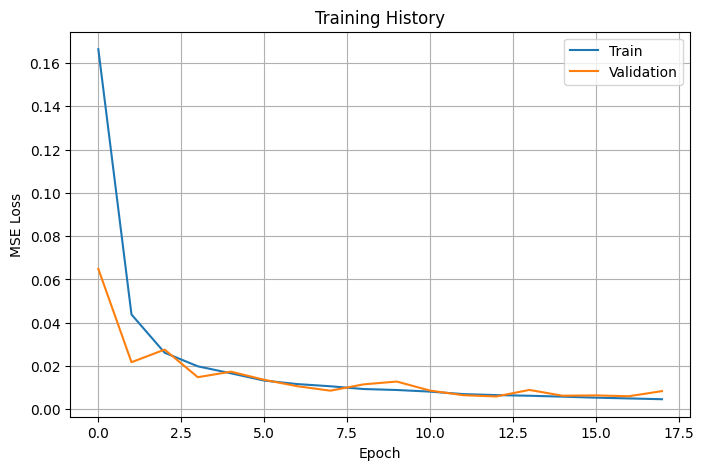

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train")

plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title("Training History")

plt.legend()

plt.grid(True)

plt.show()

In [23]:
import timm
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "xception",
    pretrained=False,
    num_classes=5
)

model.load_state_dict(torch.load(
    r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\best_xception_model.pth",
    map_location=device
))

model = model.to(device)
model.eval()

print("Model loaded successfully.")

c:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\myenv\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Model loaded successfully.


In [34]:
print(type(ground_truth))
print(type(predictions))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [35]:
import numpy as np

ground_truth = np.vstack(ground_truth)
predictions = np.vstack(predictions)

print(ground_truth.shape)
print(predictions.shape)

(544, 5)
(544, 5)


In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

parameter_names = ["p1","p2","p3","p4","p5"]

print("="*60)

for i, name in enumerate(parameter_names):

    mae = mean_absolute_error(
        ground_truth[:,i],
        predictions[:,i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            ground_truth[:,i],
            predictions[:,i]
        )
    )

    r2 = r2_score(
        ground_truth[:,i],
        predictions[:,i]
    )

    print(f"{name}")
    print(f" MAE  : {mae:.4f}")
    print(f" RMSE : {rmse:.4f}")
    print(f" R²   : {r2:.4f}")
    print()

p1
 MAE  : 0.0387
 RMSE : 0.0497
 R²   : 0.9979

p2
 MAE  : 0.0642
 RMSE : 0.0822
 R²   : 0.9930

p3
 MAE  : 0.0601
 RMSE : 0.0755
 R²   : 0.9954

p4
 MAE  : 0.0533
 RMSE : 0.0704
 R²   : 0.9959

p5
 MAE  : 0.0578
 RMSE : 0.0724
 R²   : 0.9964



In [29]:
overall_mae = np.mean(np.abs(predictions-ground_truth))

overall_rmse = np.sqrt(
    np.mean((predictions-ground_truth)**2)
)

print("Overall MAE :", overall_mae)
print("Overall RMSE:", overall_rmse)

Overall MAE : 0.054828387
Overall RMSE: 0.070885636


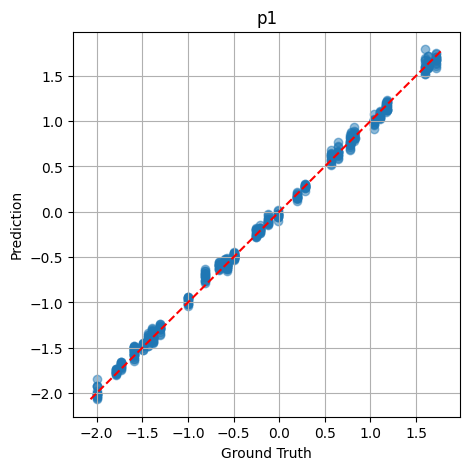

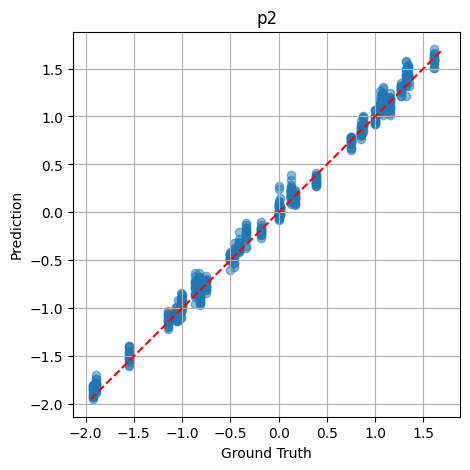

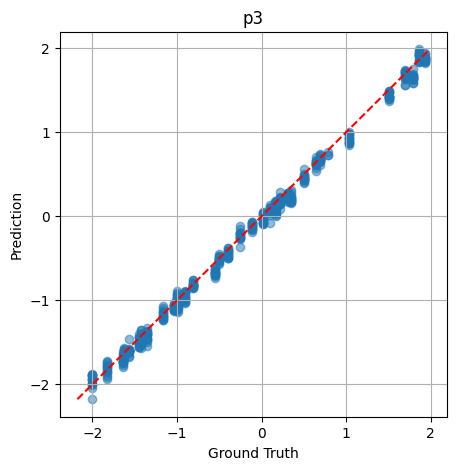

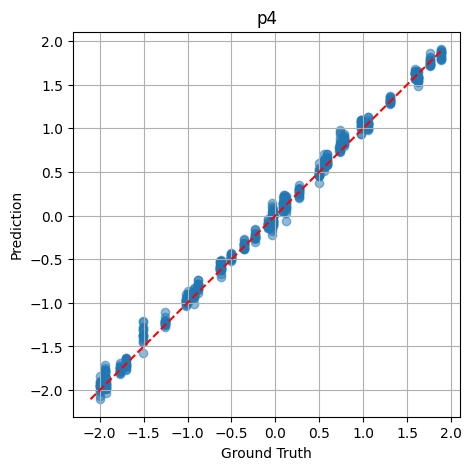

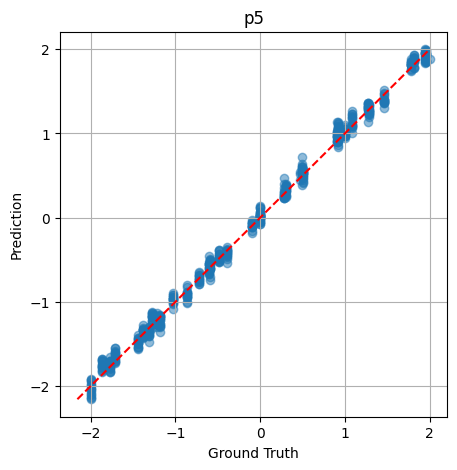

In [30]:
import matplotlib.pyplot as plt

parameter_names=["p1","p2","p3","p4","p5"]

for i,name in enumerate(parameter_names):

    plt.figure(figsize=(5,5))

    plt.scatter(
        ground_truth[:,i],
        predictions[:,i],
        alpha=0.5
    )

    mn=min(
        ground_truth[:,i].min(),
        predictions[:,i].min()
    )

    mx=max(
        ground_truth[:,i].max(),
        predictions[:,i].max()
    )

    plt.plot(
        [mn,mx],
        [mn,mx],
        'r--'
    )

    plt.xlabel("Ground Truth")
    plt.ylabel("Prediction")

    plt.title(name)

    plt.grid(True)

    plt.show()

In [37]:
import torch
import timm
from PIL import Image
from torchvision import transforms

# ==========================================================
# DEVICE
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================================
# LOAD MODEL
# ==========================================================

model = timm.create_model(
    "xception",
    pretrained=False,
    num_classes=5
)

model.load_state_dict(
    torch.load(
        r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\best_xception_model.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Model loaded.")

# ==========================================================
# PREPROCESSING
# ==========================================================

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==========================================================
# LOAD IMAGE
# ==========================================================

image_path = r"Synthetic femurs/Split/val/synthetic_femur_8_aug13.png"   # <-- change this

image = Image.open(image_path)

image = transform(image)

image = image.unsqueeze(0)          # (1,3,256,256)

image = image.to(device)

# ==========================================================
# PREDICT
# ==========================================================

with torch.no_grad():

    prediction = model(image)

prediction = prediction.squeeze().cpu().numpy()

# ==========================================================
# PRINT RESULTS
# ==========================================================

print("\nPredicted deformation parameters:\n")

for i, value in enumerate(prediction, start=1):
    print(f"p{i} = {value:.6f}")

Model loaded.

Predicted deformation parameters:

p1 = -2.014507
p2 = -1.954384
p3 = -2.077017
p4 = -1.995768
p5 = -0.055676
